
# EDA Twitter

In [1]:
%config InlineBackend.figure_formats = ['svg']
import sys
import os
import pandas as pd

# Agregar el directorio raiz al PYTHONPATH
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
# Cargar daots
from constants.constants_twitter import TWITTER_TRAIN_RAW_PATH

df_train =  pd.read_csv(TWITTER_TRAIN_RAW_PATH, header=None, encoding="utf-8")

# Establecer nombre a las columnas
df_train.columns = ['id', 'entidad', 'polarity', 'text']

Vamos a conocer los datos, ver cuantas columnas tiene y cuantos ejemplos contiene.

In [3]:
display(df_train.head())
display(df_train.tail())
print(df_train.info())

,id,entidad,polarity,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


,id,entidad,polarity,text
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...
74681,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        74682 non-null  int64 
 1   entidad   74682 non-null  object
 2   polarity  74682 non-null  object
 3   text      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None


In [4]:
from src.statistics.statistics import estadisticas_basicas


estadisticas_basicas(df_train)

--- Estadísticas para la columna: id ---
+ Promedio           : 6432.59
+ Mediana            : 6422.0
+ Moda               : 1
+ Varianza           : 13990800.65
+ Desviación estándar: 3740.43
+ Mínimo             : 1
+ Máximo             : 13200
+ Rango              : 13199
+ Valores nulos: 0 - 0.00%

--- Estadísticas para la columna: entidad ---
Total de elementos de la columna entidad: 74682
+ TomClancysRainbowSix             : 2400 - 3.21%
+ MaddenNFL                        : 2400 - 3.21%
+ Microsoft                        : 2400 - 3.21%
+ LeagueOfLegends                  : 2394 - 3.21%
+ CallOfDuty                       : 2394 - 3.21%
+ Verizon                          : 2382 - 3.19%
+ CallOfDutyBlackopsColdWar        : 2376 - 3.18%
+ ApexLegends                      : 2376 - 3.18%
+ Facebook                         : 2370 - 3.17%
+ WorldOfCraft                     : 2364 - 3.17%
+ Dota2                            : 2364 - 3.17%
+ NBA2K                            : 2352 - 3.15%
+ 

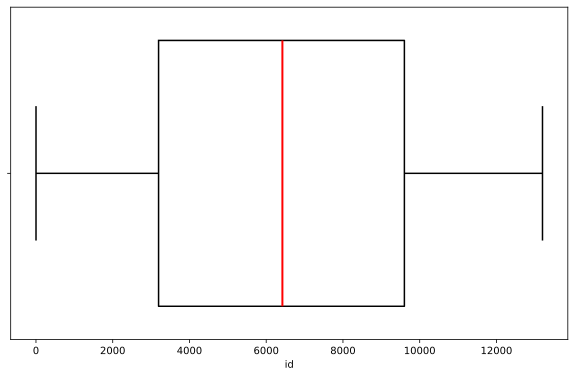

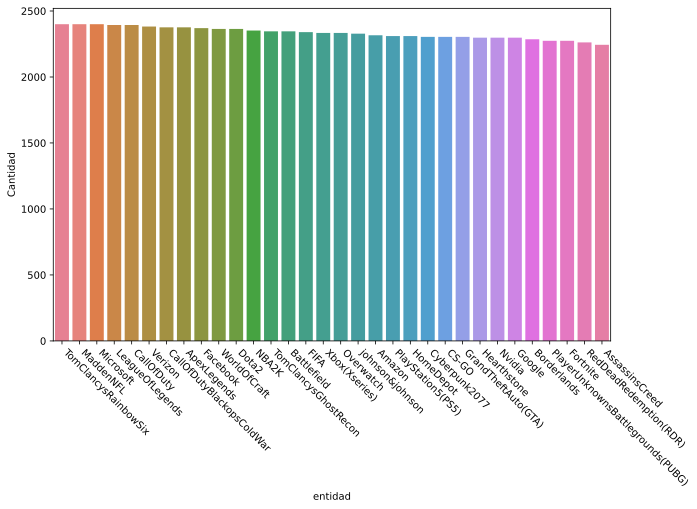

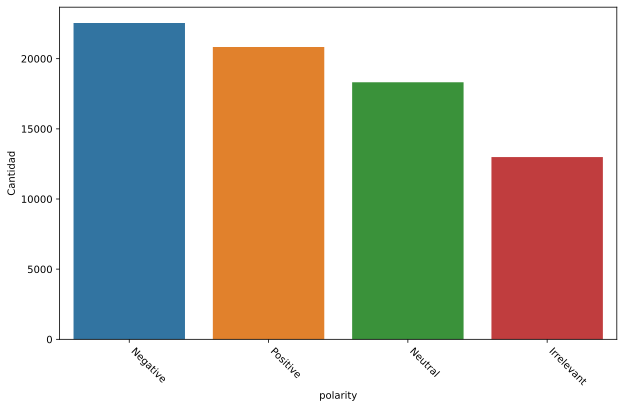

Gráficos de la variable text omitidos


In [5]:
from src.statistics.statistics_plots import visualizacion_datos

visualizacion_datos(df_train)

## Análisis profundo

### Campo text

#### Número de palabras por texto

+ Promedio           : 19.23
+ Mediana            : 16.0
+ Moda               : 12.0
+ Varianza           : 208.59
+ Desviación estándar: 14.44
+ Mínimo             : 0.0
+ Máximo             : 198.0
+ Rango              : 198.0


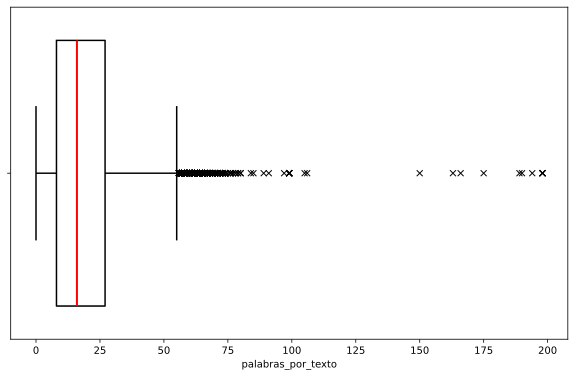

In [6]:
from src.statistics.statistics import estadisticas_numericas
from src.statistics.statistics_plots import grafica_numerica

palabras_por_texto = df_train["text"].str.split().str.len().to_frame("palabras_por_texto")

estadisticas_numericas(palabras_por_texto, "palabras_por_texto")
grafica_numerica(palabras_por_texto, "palabras_por_texto")

#### Palabras frecuentes

In [7]:
from src.statistics.statistics import estadisticas_vocabulario

print("Palabras más frecuentes")
print(estadisticas_vocabulario(df_train, 'text', False, None))

Palabras más frecuentes
Palabras únicas:  31063
           Palabra  Frecuencia
0              the       44611
1               to       29042
2              and       26712
3               of       19528
4               it       17941
...            ...         ...
31058        4ty6b           1
31059  progressing           1
31060          otv           1
31061      fancing           1
31062      proxies           1

[31063 rows x 2 columns]


## Limpieza

In [8]:
# Eliminar textos etiquetados como irrelevantes
df_train = df_train[df_train['polarity'] != 'Irrelevant'].reset_index(drop=True)
print(df_train.info())

# Eliminar columnas innecesarias
df_train = df_train.drop(columns=["id", "entidad"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61692 entries, 0 to 61691
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        61692 non-null  int64 
 1   entidad   61692 non-null  object
 2   polarity  61692 non-null  object
 3   text      61121 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.9+ MB
None


In [9]:
from src.preprocesamiento.nlp_spacy import preprocesamiento
from src.preprocesamiento.clean import (clean_text, drop_blank_or_nan)
from tqdm import tqdm
tqdm.pandas()

df_train['text'] = df_train['text'].astype("string")
df_train = drop_blank_or_nan(df_train, 'text') # Eliminar nan
# Limpieza y correción ortográfica
df_train['text'] = df_train['text'].progress_apply(clean_text, lang="en")
df_train= drop_blank_or_nan(df_train, 'text') # Eliminar filas sin texto
# NLP (tokenización, no stop words, lematización, stemming)
df_train['text'] = preprocesamiento(df_train['text'], stemming=True, lang="en", progress=True)
df_train = drop_blank_or_nan(df_train, 'text') # Eliminar filas sin texto
df_train.info()

  0%|          | 0/60982 [00:00<?, ?it/s]c:\Users\Diego\Desktop\sentiment_analysis\src\preprocesamiento\clean.py:90: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, 'html.parser')
100%|██████████| 60982/60982 [03:38<00:00, 279.15it/s]


Modelo cargado: en_core_web_sm


nlp.pipe: 100%|██████████| 60734/60734 [02:10<00:00, 467.07it/s]


Aplicando stemming...
Total de documentos preprocesados: 60734
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59476 entries, 0 to 59475
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   polarity  59476 non-null  object
 1   text      59476 non-null  object
dtypes: object(2)
memory usage: 929.4+ KB


polarity
NEG    21824
POS    20069
NEU    17583
Name: count, dtype: int64


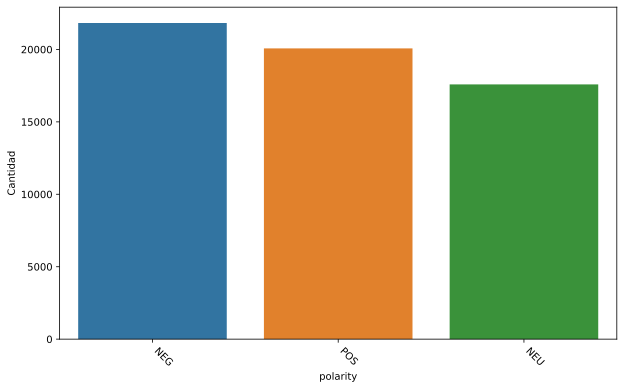

Gráficos de la variable text omitidos


In [10]:
# Mapear etiquetas
from constants.constants_nlp import POLARITY_MAP

TWITTER_POLARITY_MAP = { "Negative": "NEG", "Neutral": "NEU", "Positive": "POS" }
df_train['polarity'] = df_train['polarity'].map(TWITTER_POLARITY_MAP)
print(df_train['polarity'].value_counts())
visualizacion_datos(df_train)

In [11]:
df_train['polarity'] = df_train['polarity'].map(POLARITY_MAP)

## Guardar datos para entrenamiento


In [ ]:
from constants.constants_twitter import TWITTER_DATASET_TRAIN_PATH, TWITTER_DATASET_VAL_PATH

df_train.to_csv(TWITTER_DATASET_TRAIN_PATH, index=False)
print(f"Archivo guardado en: {TWITTER_DATASET_TRAIN_PATH}")